In [1]:
# Autoencoders and VAE
# Unsupervised learning, generative models, latent representations

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

## Defining the Loss Function

The loss function measures how wrong our predictions are. During training, we'll minimize this value. Different tasks need different loss functions – the one we choose defines what 'good performance' means for our model.


In [2]:
# Define a custom function with detailed implementation
## Basic Autoencoder
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed, z

print("Autoencoder: Unsupervised learning of compressed representation")
print("Loss: Reconstruction error (MSE)")
print("Applications: Denoising, dimensionality reduction, anomaly detection")


Autoencoder: Unsupervised learning of compressed representation
Loss: Reconstruction error (MSE)
Applications: Denoising, dimensionality reduction, anomaly detection


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [3]:
# Define a custom function with detailed implementation
## Variational Autoencoder
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )
        self.mu = nn.Linear(128, latent_dim)
        self.logvar = nn.Linear(128, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid()
        )
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z
    
    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.mu(h), self.logvar(h)
# Update model parameters based on computed gradients
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

print("\nVAE: Probabilistic generative model")
print("Loss: Reconstruction + KL divergence")
print("Advantage: Smooth latent space, can sample")
print("Applications: Image generation, interpolation")



VAE: Probabilistic generative model
Loss: Reconstruction + KL divergence
Advantage: Smooth latent space, can sample
Applications: Image generation, interpolation


## Defining the Loss Function

The loss function measures how wrong our predictions are. During training, we'll minimize this value. Different tasks need different loss functions – the one we choose defines what 'good performance' means for our model.


In [4]:
## VAE Loss Function
def vae_loss(recon, x, mu, logvar):
    # Reconstruction loss
    recon_loss = nn.functional.mse_loss(recon, x, reduction='mean')
    
    # KL divergence (regularizer)
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + kl_loss

print("VAE Loss Components:")
print("1. Reconstruction: MSE/BCE (data fit)")
print("2. KL divergence: regularization (match prior)")
print("3. Beta-VAE: weight KL term for disentanglement")

VAE Loss Components:
1. Reconstruction: MSE/BCE (data fit)
2. KL divergence: regularization (match prior)
3. Beta-VAE: weight KL term for disentanglement


## Defining the Loss Function

The loss function measures how wrong our predictions are. During training, we'll minimize this value. Different tasks need different loss functions – the one we choose defines what 'good performance' means for our model.


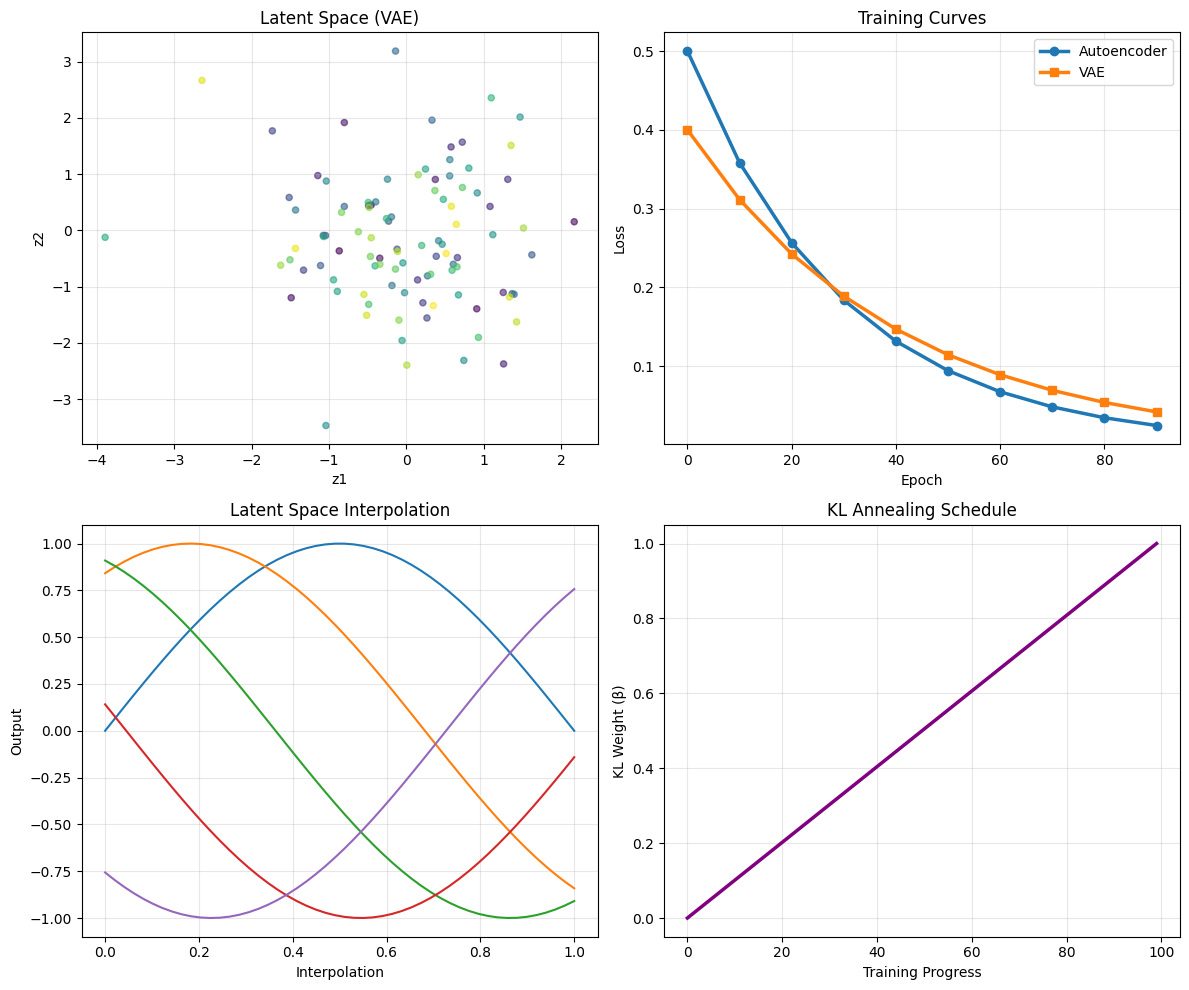

In [5]:
# Configure loss function and optimization algorithm
## Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Latent space visualization
z1 = np.random.randn(100)
z2 = np.random.randn(100)
axes[0, 0].scatter(z1, z2, c=np.arange(100), cmap='viridis', s=20, alpha=0.6)
axes[0, 0].set_xlabel('z1')
axes[0, 0].set_ylabel('z2')
axes[0, 0].set_title('Latent Space (VAE)')
axes[0, 0].grid(True, alpha=0.3)

# Reconstruction quality
epochs = np.arange(0, 100, 10)
# Compute the loss (error) between predictions and actual values
autoencoder_loss = 0.5 * np.exp(-epochs/30)
# Compute the loss (error) between predictions and actual values
vae_loss_curve = 0.4 * np.exp(-epochs/40)
# Compute the loss (error) between predictions and actual values
axes[0, 1].plot(epochs, autoencoder_loss, marker='o', label='Autoencoder', linewidth=2.5)
# Compute the loss (error) between predictions and actual values
axes[0, 1].plot(epochs, vae_loss_curve, marker='s', label='VAE', linewidth=2.5)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Training Curves')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Latent interpolation
# Iterate through batches of data
for i in range(5):
    axes[1, 0].plot(np.linspace(0, 1, 50), np.sin(np.linspace(0, np.pi, 50) + i))
axes[1, 0].set_xlabel('Interpolation')
axes[1, 0].set_ylabel('Output')
axes[1, 0].set_title('Latent Space Interpolation')
axes[1, 0].grid(True, alpha=0.3)

# KL divergence schedule
lambda_vals = np.linspace(0, 1, 100)
axes[1, 1].plot(lambda_vals, color='purple', linewidth=2.5)
axes[1, 1].set_xlabel('Training Progress')
axes[1, 1].set_ylabel('KL Weight (β)')
axes[1, 1].set_title('KL Annealing Schedule')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Key Takeaways
- Autoencoders: unsupervised learning of data compression
# Iterate through batches of data
- VAE: probabilistic, smooth latent space for generation
- Reconstruction loss: measures data fitting
- KL divergence: ensures latent follows prior (N(0,I))
- Reparameterization trick: enables backprop through sampling
- Applications: generation, interpolation, anomaly detection

## References
- [VAE Paper](https://arxiv.org/abs/1312.6114)
